# Amazon Electronics Intelligence

A Data Science project analyzing product reviews from the Amazon Electronics category.

**Dataset:** Amazon Electronics 5-core (reviews_Electronics_5.json)  
**Source:** [Julian McAuley, UCSD](http://jmcauley.ucsd.edu/data/amazon/)

In [1]:
# Required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

---
## 1. Data Loading & Initial Overview

The dataset contains product reviews from the Amazon Electronics category. Each row is a JSON object (line-delimited JSON format).

In [2]:
# Load the dataset
df = pd.read_json('../../reviews_Electronics_5.json/Electronics_5.json', lines=True)
print(f'Dataset loaded successfully!')
print(f'Number of rows: {df.shape[0]:,}')
print(f'Number of columns: {df.shape[1]}')

Dataset loaded successfully!
Number of rows: 1,689,188
Number of columns: 9


In [3]:
# First 5 rows
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,AO94DHGC771SJ,0528881469,amazdnu,"[0, 0]",We got this GPS for my husband who is an (OTR) over the road trucker. Very Impressed with the s...,5,Gotta have GPS!,1370131200,"06 2, 2013"
1,AMO214LNFCEI4,0528881469,Amazon Customer,"[12, 15]","I'm a professional OTR truck driver, and I bought a TND 700 at a truck stop hoping to make my li...",1,Very Disappointed,1290643200,"11 25, 2010"
2,A3N7T0DY83Y4IG,0528881469,C. A. Freeman,"[43, 45]","Well, what can I say. I've had this unit in my truck for about four days now. Prior to that I ...",3,1st impression,1283990400,"09 9, 2010"
3,A1H8PY3QHMQQA0,0528881469,"Dave M. Shaw ""mack dave""","[9, 10]","Not going to write a long review, even thought this unit deserves one. I've driven well over 1-m...",2,"Great grafics, POOR GPS",1290556800,"11 24, 2010"
4,A24EV6RXELQZ63,0528881469,Wayne Smith,"[0, 0]",I've had mine for a year and here's what we got. It tries to route be down non truck routes whil...,1,"Major issues, only excuses for support",1317254400,"09 29, 2011"


In [4]:
# Column types and null info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1689188 entries, 0 to 1689187
Data columns (total 9 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   reviewerID      1689188 non-null  object
 1   asin            1689188 non-null  object
 2   reviewerName    1664458 non-null  object
 3   helpful         1689188 non-null  object
 4   reviewText      1689188 non-null  object
 5   overall         1689188 non-null  int64 
 6   summary         1689188 non-null  object
 7   unixReviewTime  1689188 non-null  int64 
 8   reviewTime      1689188 non-null  object
dtypes: int64(2), object(7)
memory usage: 116.0+ MB


In [5]:
# Summary statistics for numerical columns
df.describe()

,overall,unixReviewTime
count,1.689188e+06,1.689188e+06
mean,4.222779e+00,1.340571e+09
std,1.185632e+00,6.342451e+07
min,1.000000e+00,9.292320e+08
25%,4.000000e+00,1.318118e+09
50%,5.000000e+00,1.360800e+09
75%,5.000000e+00,1.385078e+09
max,5.000000e+00,1.406074e+09


### Column Descriptions

| Column | Description |
|--------|-------------|
| `reviewerID` | Unique identifier of the reviewer |
| `asin` | Amazon Standard Identification Number (unique product ID) |
| `reviewerName` | Display name of the reviewer |
| `helpful` | Helpfulness votes - [number of helpful votes, total votes] |
| `reviewText` | Full text of the review |
| `overall` | Product rating (1.0 - 5.0) |
| `summary` | Short title/summary of the review |
| `unixReviewTime` | Timestamp of the review (Unix epoch) |
| `reviewTime` | Date of the review (human-readable format) |

In [6]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Rate (%)': missing_pct
})

print('Missing Value Summary:')
print('=' * 40)
missing_df

Missing Value Summary:


,Missing Count,Missing Rate (%)
reviewerID,0,0.00
asin,0,0.00
reviewerName,24730,1.46
helpful,0,0.00
reviewText,0,0.00
overall,0,0.00
summary,0,0.00
unixReviewTime,0,0.00
reviewTime,0,0.00


In [7]:
# Unique value counts
print('Unique Values per Column:')
print('=' * 40)
for col in df.columns:
    try:
        print(f'{col:20s} -> {df[col].nunique():>10,} unique values')
    except TypeError:
        print(f'{col:20s} ->  (unhashable type, skipped)')


Unique Values per Column:
reviewerID           ->    192,403 unique values
asin                 ->     63,001 unique values
reviewerName         ->    162,859 unique values
helpful              ->  (unhashable type, skipped)
reviewText           ->  1,687,169 unique values
overall              ->          5 unique values
summary              ->  1,139,738 unique values
unixReviewTime       ->      5,277 unique values
reviewTime           ->      5,277 unique values


---
## 2. Descriptive Statistics

Getting the big picture of the dataset through rating distribution, most reviewed products, and most active reviewers.

### 2.1 Rating Distribution

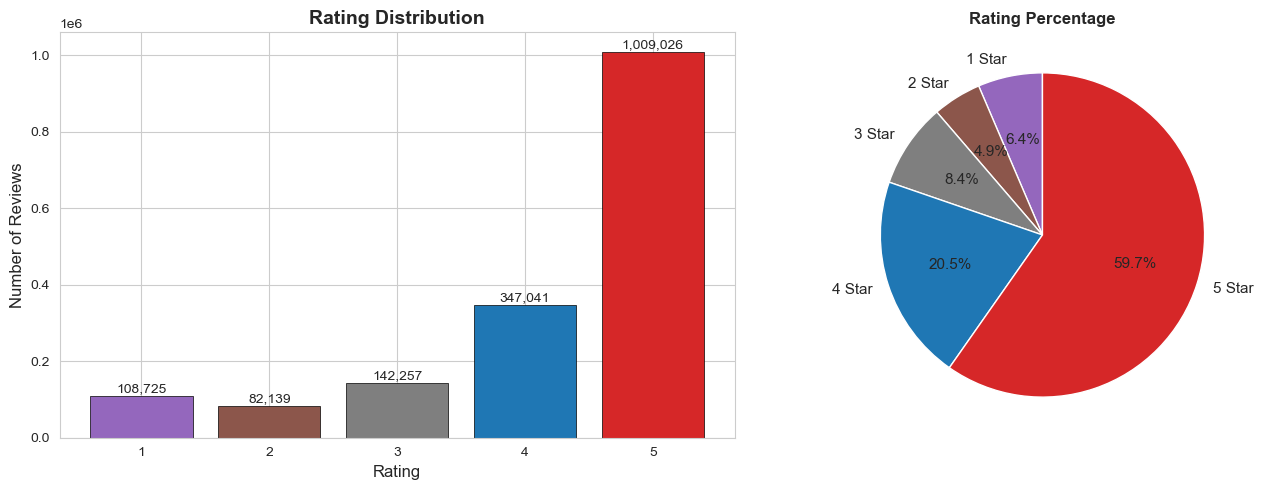

Average Rating: 4.22
Median Rating: 5.0
Mode Rating: 5.0


In [8]:
# Rating distribution
rating_counts = df['overall'].value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Bar chart
colors = ['#9467bd', '#8c564b', '#7f7f7f', '#1f77b4', '#d62728']
ax[0].bar(rating_counts.index, rating_counts.values, color=colors , edgecolor='black', linewidth=0.5)
ax[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Rating', fontsize=12)
ax[0].set_ylabel('Number of Reviews', fontsize=12)
ax[0].set_xticks([1, 2, 3, 4, 5])

# Percentage pie chart
for i, v in enumerate(rating_counts.values):
    offset = rating_counts.max() * 0.01
    ax[0].text(rating_counts.index[i], v + offset, f'{v:,}', ha='center', fontsize=10)
    
ax[1].pie(rating_counts.values, labels=[f'{int(r)} Star' for r in rating_counts.index], autopct='%1.1f%%',
       colors=colors, startangle=90, textprops={'fontsize': 11})
ax[1].set_title('Rating Percentage', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


print(f'Average Rating: {df["overall"].mean():.2f}')
print(f'Median Rating: {df["overall"].median():.1f}')
print(f'Mode Rating: {df["overall"].mode()[0]:.1f}')

### 2.2 Most Reviewed Products (Top 10)

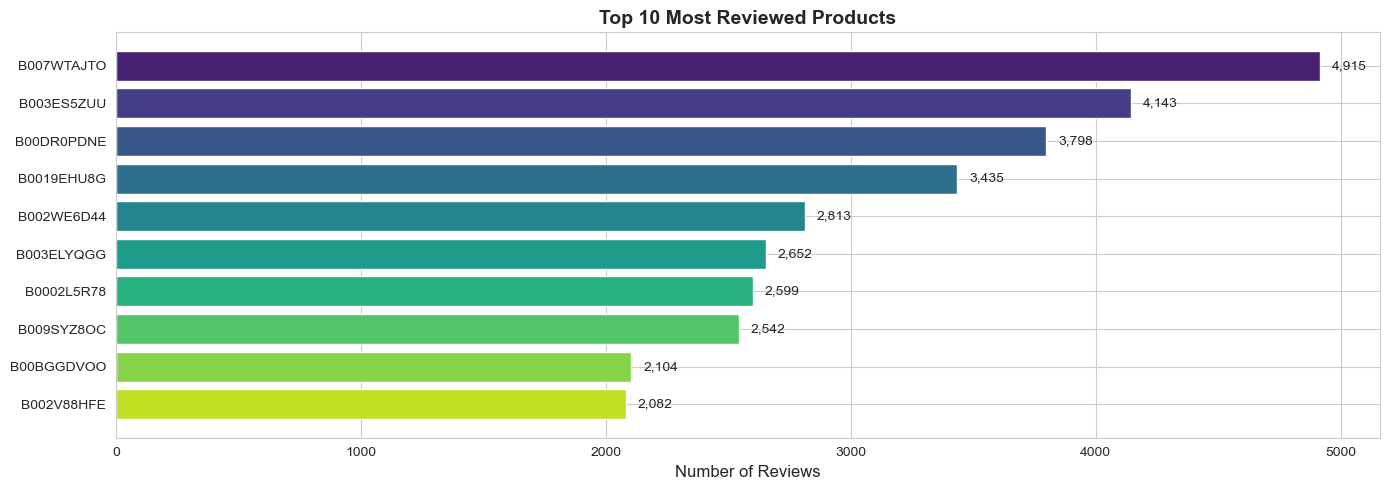

Total unique products: 63,001
Average reviews per product: 26.8


In [9]:
# Top 10 most reviewed products
top_products = df['asin'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(14,5))

ax.barh(range(len(top_products)), top_products.values, color=sns.color_palette('viridis',10))
ax.set_yticks(range(len(top_products)))
ax.set_yticklabels(top_products.index, fontsize=10)
ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_title('Top 10 Most Reviewed Products' ,fontsize=14, fontweight='bold')
ax.invert_yaxis()

offset=top_products.max()*0.01
for i,v in enumerate(top_products.values):
    ax.text(v + offset, i, f'{v:,}', va='center', fontsize=10)
    
plt.tight_layout()
plt.show()

print(f'Total unique products: {df["asin"].nunique():,}')
print(f'Average reviews per product: {df.groupby("asin").size().mean():.1f}')


### 2.3 Most Active Reviewers (Top 10)

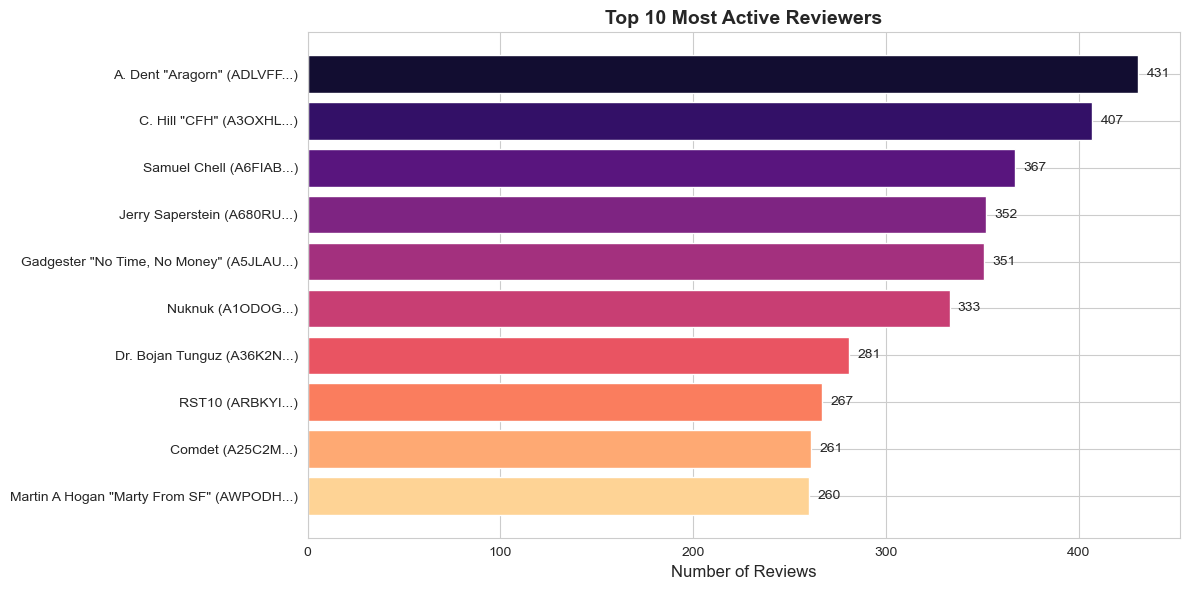

Total unique reviewers: 192,403
Average reviews per user: 8.8


In [10]:
# Top 10 most active reviewers
top_reviewers = df['reviewerID'].value_counts().head(10)

# Get reviewer names where available
reviewer_names = df.drop_duplicates('reviewerID').set_index('reviewerID')['reviewerName']
labels = [f'{reviewer_names.get(rid, "Unknown")} ({rid[:6]}...)' for rid in top_reviewers.index]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_reviewers)), top_reviewers.values, color=sns.color_palette('magma', 10))
ax.set_yticks(range(len(top_reviewers)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_title('Top 10 Most Active Reviewers', fontsize=14, fontweight='bold')
ax.invert_yaxis()

offset=top_reviewers.max()*0.01
for i, v in enumerate(top_reviewers.values):
    ax.text(v + offset, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Total unique reviewers: {df["reviewerID"].nunique():,}')
print(f'Average reviews per user: {df.groupby("reviewerID").size().mean():.1f}')

---
## 3. Temporal Analysis

Let's look at how reviews are distributed over time.

In [11]:
# Convert unix timestamp to datetime and extract time components
df['review_date'] = pd.to_datetime(df['unixReviewTime'], unit='s')
df['review_year'] = df['review_date'].dt.year
df['review_month'] = df['review_date'].dt.month
df['review_ym'] = df['review_date'].dt.to_period('M')

print(f"Reviews span from {df['review_date'].min():%Y-%m-%d} to {df['review_date'].max():%Y-%m-%d}")
print(f"That's {(df['review_date'].max() - df['review_date'].min()).days:,} days of data")

Reviews span from 1999-06-13 to 2014-07-23
That's 5,519 days of data


### 3.1 Yearly Review Volume

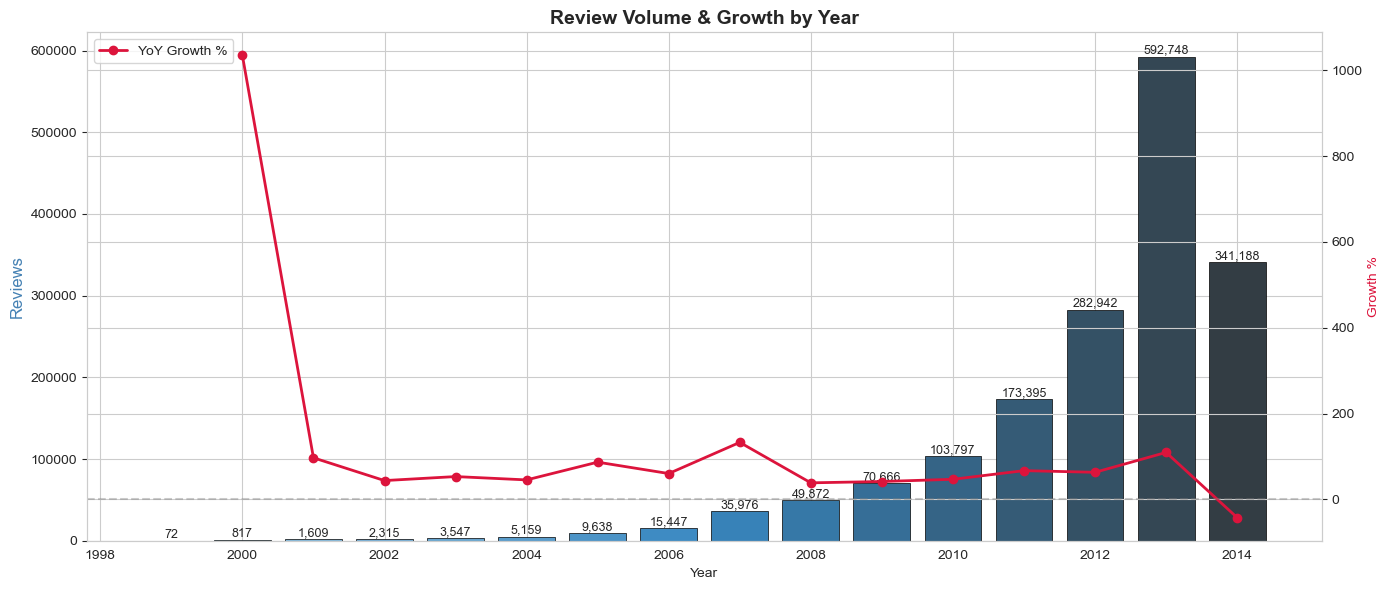

,review_year,count,growth
0,1999,72,NaN
1,2000,817,1034.722222
2,2001,1609,96.940024
3,2002,2315,43.878185
4,2003,3547,53.218143
5,2004,5159,45.446856
6,2005,9638,86.819151
7,2006,15447,60.271841
8,2007,35976,132.899592
9,2008,49872,38.625751


In [12]:
# Count reviews per year and calculate year-over-year growth
yearly = df.groupby('review_year').size().reset_index(name='count')
yearly['growth'] = yearly['count'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart: review volume
bars = ax1.bar(yearly['review_year'], yearly['count'],
               color=sns.color_palette('Blues_d', len(yearly)),
               edgecolor='black', lw=0.5)
ax1.set_ylabel('Reviews', fontsize=12, color='steelblue')
ax1.set_xlabel('Year')

# Add count labels
for b, c in zip(bars, yearly['count']):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height(),
             f'{c:,}', ha='center', va='bottom', fontsize=9)

# Line chart: YoY growth rate
ax2 = ax1.twinx()
ax2.plot(yearly['review_year'].iloc[1:], yearly['growth'].iloc[1:],
         'o-', color='crimson', lw=2, label='YoY Growth %')
ax2.set_ylabel('Growth %', color='crimson')
ax2.axhline(0, color='gray', ls='--', alpha=0.4)
ax2.legend(loc='upper left')

ax1.set_title('Review Volume & Growth by Year', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

yearly

### 3.2 Seasonality

Do November (Black Friday) and December show any spikes in reviews or shifts in ratings?

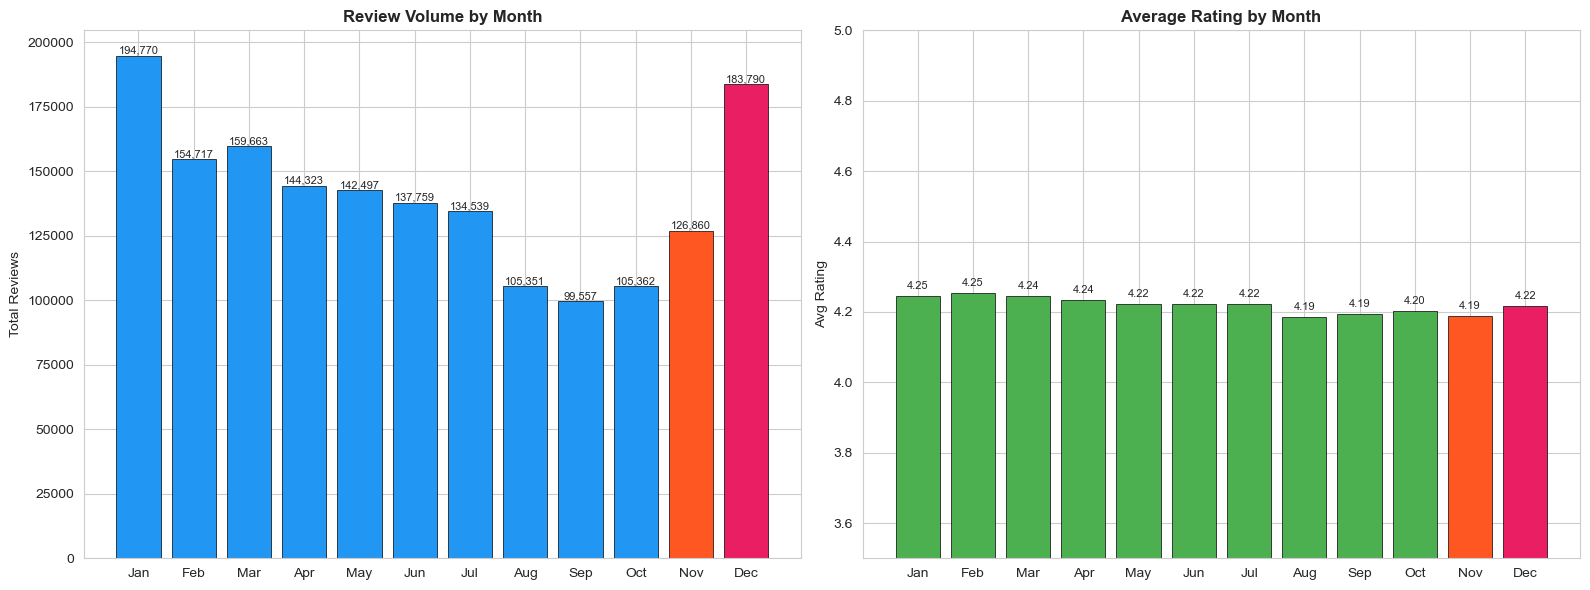

November: 126,860 reviews (-9.9% vs avg), rating 4.19 (-0.034 vs 4.22)
December: 183,790 reviews (+30.6% vs avg), rating 4.22 (-0.006 vs 4.22)


In [13]:
# Aggregate review volume and average rating by month
monthly_vol = df.groupby('review_month').size()
monthly_rating = df.groupby('review_month')['overall'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Highlight Nov and Dec with different colors
vol_colors = ['#2196F3']*10 + ['#FF5722', '#E91E63']
rat_colors = ['#4CAF50']*10 + ['#FF5722', '#E91E63']

# Left: total reviews per month
ax1.bar(range(1,13), monthly_vol.values, color=vol_colors, edgecolor='black', lw=0.5)
ax1.set_xticks(range(1,13)); ax1.set_xticklabels(months)
ax1.set_title('Review Volume by Month', fontweight='bold')
ax1.set_ylabel('Total Reviews')
for i, v in enumerate(monthly_vol.values):
    ax1.text(i+1, v, f'{v:,}', ha='center', va='bottom', fontsize=8)

# Right: average rating per month
ax2.bar(range(1,13), monthly_rating.values, color=rat_colors, edgecolor='black', lw=0.5)
ax2.set_xticks(range(1,13)); ax2.set_xticklabels(months)
ax2.set_title('Average Rating by Month', fontweight='bold')
ax2.set_ylabel('Avg Rating')
ax2.set_ylim(3.5, 5.0)
for i, v in enumerate(monthly_rating.values):
    ax2.text(i+1, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# Compare Nov/Dec against overall averages
avg_monthly = monthly_vol.mean()
avg_rating = df['overall'].mean()
for m, name in [(11,'November'), (12,'December')]:
    vol_diff = (monthly_vol[m] - avg_monthly) / avg_monthly * 100
    rat_diff = monthly_rating[m] - avg_rating
    print(f"{name}: {monthly_vol[m]:,} reviews ({vol_diff:+.1f}% vs avg), "
          f"rating {monthly_rating[m]:.2f} ({rat_diff:+.3f} vs {avg_rating:.2f})")

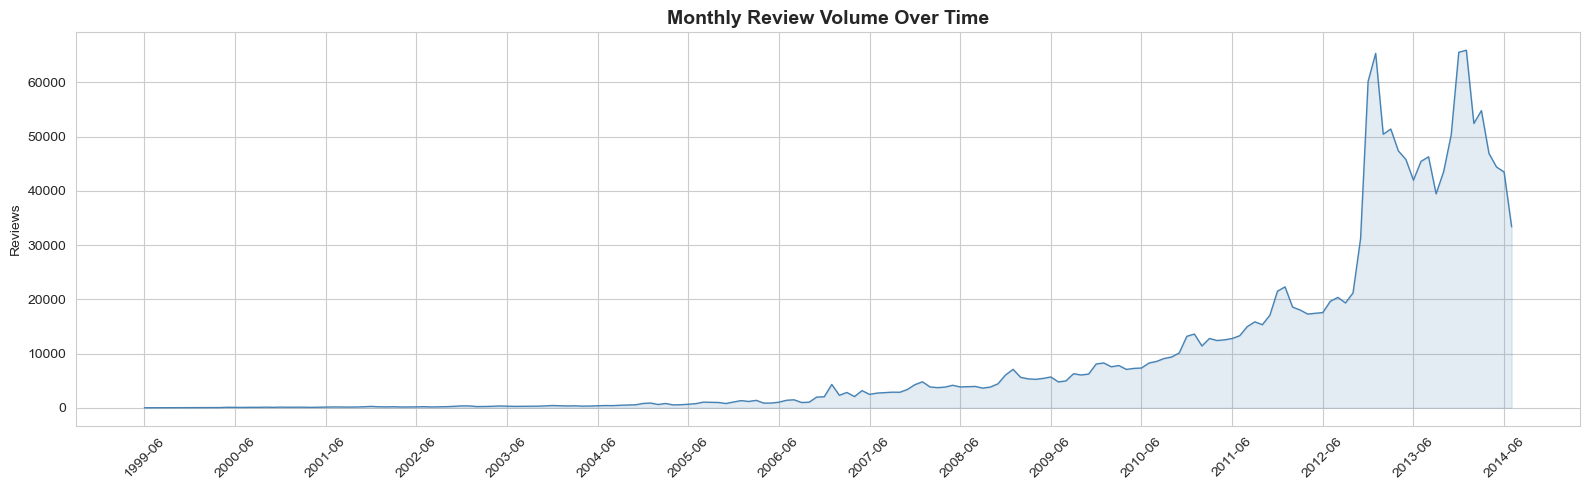

In [14]:
# Monthly review volume trend over the full time period
ym = df.groupby('review_ym').size()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ym.index.astype(str), ym.values, color='steelblue', lw=1)
ax.fill_between(range(len(ym)), ym.values, alpha=0.15, color='steelblue')

# Show one tick per year for readability
ticks = list(range(0, len(ym), 12))
ax.set_xticks(ticks)
ax.set_xticklabels([ym.index.astype(str)[i] for i in ticks], rotation=45)
ax.set_title('Monthly Review Volume Over Time', fontweight='bold', fontsize=14)
ax.set_ylabel('Reviews')
plt.tight_layout()
plt.show()

### 3.3 Product Lifespan

How long does a product stay "alive" in terms of receiving reviews?

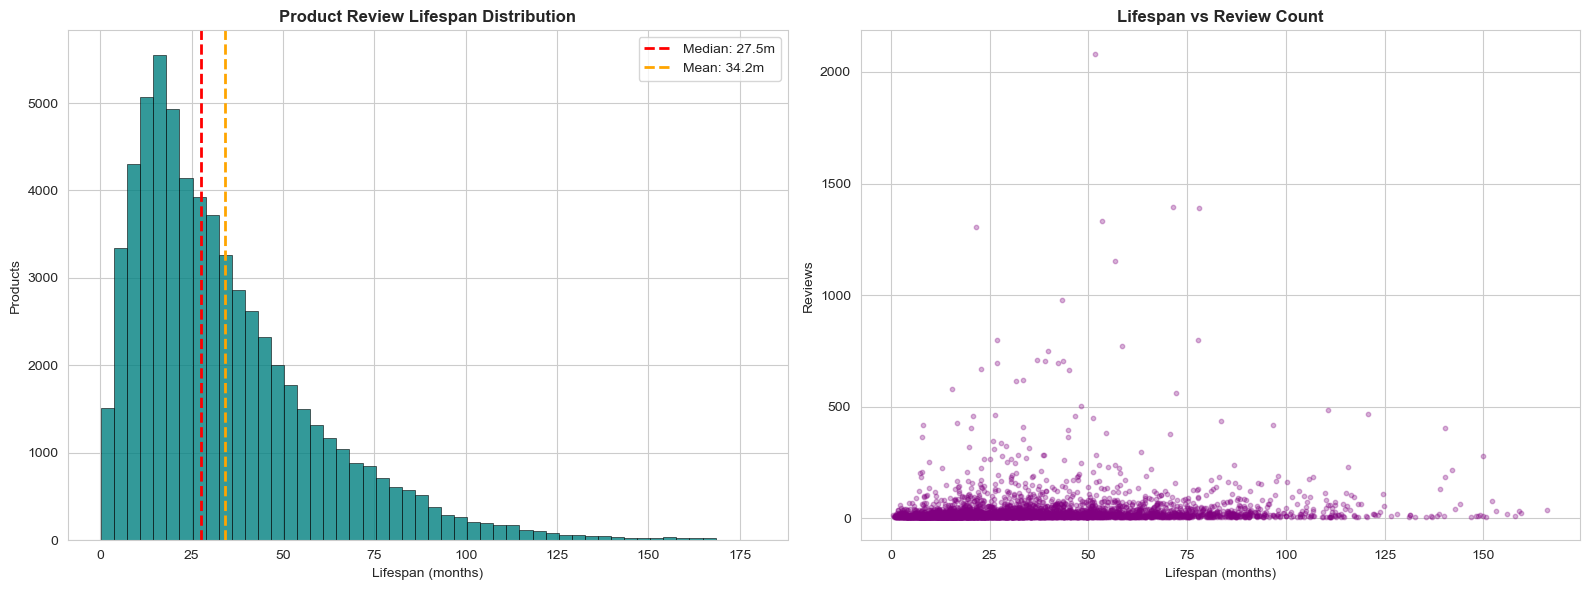

63,001 products with 2+ reviews
Mean lifespan: 34.2 months
Median lifespan: 27.5 months

< 1 month:  150 (0.2%)
< 6 months: 3,462 (5.5%)
< 1 year:   10,670 (16.9%)
> 3 years:  23,202 (36.8%)


In [15]:
# Calculate time between first and last review for each product
lifespan = df.groupby('asin')['review_date'].agg(['min','max','count'])
lifespan.columns = ['first', 'last', 'n_reviews']
lifespan['days'] = (lifespan['last'] - lifespan['first']).dt.days
lifespan['months'] = lifespan['days'] / 30.44

# Only products with 2+ reviews (single-review products have lifespan=0 by definition)
ls = lifespan[lifespan['n_reviews'] >= 2].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: lifespan distribution with mean/median markers
ax1.hist(ls['months'], bins=50, color='teal', edgecolor='black', lw=0.5, alpha=0.8)
ax1.axvline(ls['months'].median(), color='red', ls='--', lw=2,
            label=f"Median: {ls['months'].median():.1f}m")
ax1.axvline(ls['months'].mean(), color='orange', ls='--', lw=2,
            label=f"Mean: {ls['months'].mean():.1f}m")
ax1.set_xlabel('Lifespan (months)')
ax1.set_ylabel('Products')
ax1.set_title('Product Review Lifespan Distribution', fontweight='bold')
ax1.legend()

# Right: scatter plot — more reviews = longer lifespan?
sample = ls.sample(min(5000, len(ls)), random_state=42)
ax2.scatter(sample['months'], sample['n_reviews'], alpha=0.3, s=10, c='purple')
ax2.set_xlabel('Lifespan (months)')
ax2.set_ylabel('Reviews')
ax2.set_title('Lifespan vs Review Count', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary stats
print(f"{len(ls):,} products with 2+ reviews")
print(f"Mean lifespan: {ls['months'].mean():.1f} months")
print(f"Median lifespan: {ls['months'].median():.1f} months")
print(f"\n< 1 month:  {(ls['months'] < 1).sum():,} ({(ls['months'] < 1).mean()*100:.1f}%)")
print(f"< 6 months: {(ls['months'] < 6).sum():,} ({(ls['months'] < 6).mean()*100:.1f}%)")
print(f"< 1 year:   {(ls['months'] < 12).sum():,} ({(ls['months'] < 12).mean()*100:.1f}%)")
print(f"> 3 years:  {(ls['months'] > 36).sum():,} ({(ls['months'] > 36).mean()*100:.1f}%)")

  p10: 8.5 months
  p25: 15.4 months
  p50: 27.5 months
  p75: 46.2 months
  p90: 69.5 months
  p95: 85.1 months


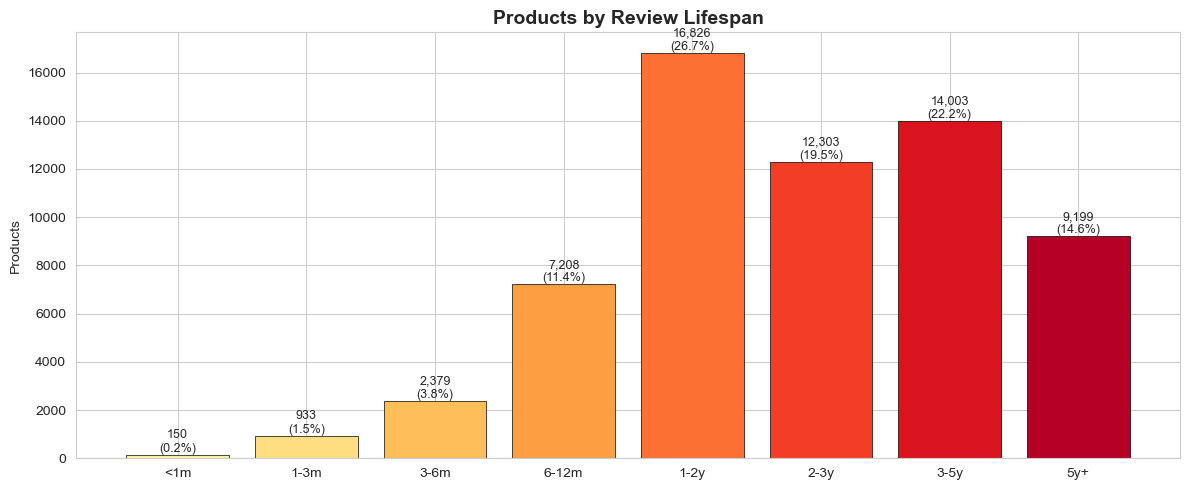

In [16]:
# Percentile breakdown of product lifespan
for p in [10, 25, 50, 75, 90, 95]:
    print(f"  p{p}: {np.percentile(ls['months'], p):.1f} months")

# Group products into lifespan categories
ls['bucket'] = pd.cut(ls['months'],
                      bins=[0,1,3,6,12,24,36,60,float('inf')],
                      labels=['<1m','1-3m','3-6m','6-12m','1-2y','2-3y','3-5y','5y+'],
                      right=False)

bc = ls['bucket'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(bc.index.astype(str), bc.values,
       color=sns.color_palette('YlOrRd', len(bc)), edgecolor='black', lw=0.5)
ax.set_title('Products by Review Lifespan', fontweight='bold', fontsize=14)
ax.set_ylabel('Products')

for i, v in enumerate(bc.values):
    ax.text(i, v, f'{v:,}\n({v/len(ls)*100:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. Statistical Inference

Time for some hypothesis testing.

### 4.1 Review Length vs Rating

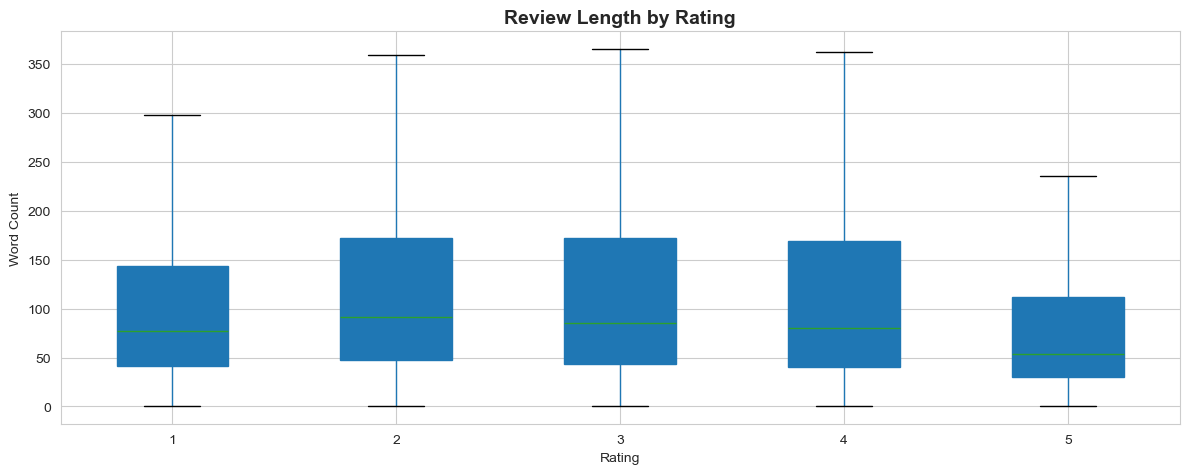

Average word count per rating:
  1 star: mean=119.9, median=77
  2 star: mean=141.7, median=91
  3 star: mean=142.9, median=85
  4 star: mean=142.5, median=80
  5 star: mean=101.1, median=54


In [17]:
# Calculate word count for each review
df['word_count'] = df['reviewText'].fillna('').apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(12, 5))
bp = df.boxplot(column='word_count', by='overall', ax=ax,
                showfliers=False, patch_artist=True)

colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
for patch, color in zip(bp.artists if hasattr(bp, 'artists') else ax.patches, colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Review Length by Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Word Count')
fig.suptitle('')

plt.tight_layout()
plt.show()

# Average word count per rating
print("Average word count per rating:")
for rating in sorted(df['overall'].unique()):
    avg = df[df['overall'] == rating]['word_count'].mean()
    med = df[df['overall'] == rating]['word_count'].median()
    print(f"  {int(rating)} star: mean={avg:.1f}, median={med:.0f}")

Spearman correlation: -0.1733
p-value: 0.00e+00

Statistically significant negative correlation (p < 0.05)


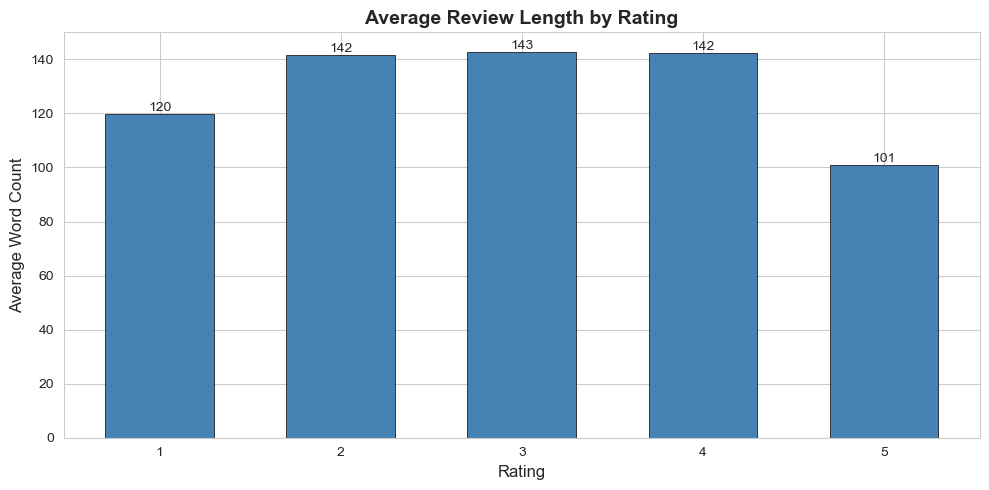

In [18]:
from scipy import stats

# Spearman correlation (better for non-linear relationships)
corr, pval = stats.spearmanr(df['overall'], df['word_count'])
print(f"Spearman correlation: {corr:.4f}")
print(f"p-value: {pval:.2e}")

if pval < 0.05:
    direction = "negative" if corr < 0 else "positive"
    print(f"\nStatistically significant {direction} correlation (p < 0.05)")
else:
    print("\nNo statistically significant correlation")

# Scatter plot with mean line
avg_by_rating = df.groupby('overall')['word_count'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(avg_by_rating.index, avg_by_rating.values, color='steelblue',
       edgecolor='black', lw=0.5, width=0.6)
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Average Word Count', fontsize=12)
ax.set_title('Average Review Length by Rating', fontsize=14, fontweight='bold')
ax.set_xticks([1, 2, 3, 4, 5])

for x, y in zip(avg_by_rating.index, avg_by_rating.values):
    ax.text(x, y + 1, f'{y:.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 4.2 Helpfulness Analysis

Do lower-rated reviews get more "helpful" votes?

Reviews with at least 1 vote: 725,961 (43.0%)
Average helpfulness ratio: 0.749


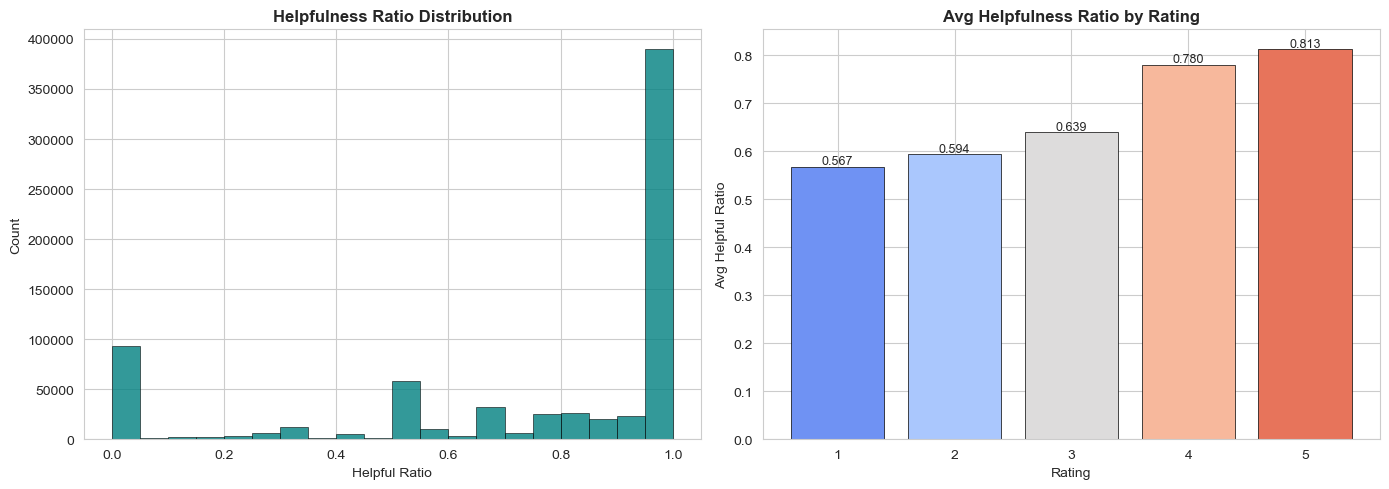

In [19]:
# Extract helpful votes and total votes from the helpful column
df['helpful_votes'] = df['helpful'].apply(lambda x: x[0])
df['total_votes'] = df['helpful'].apply(lambda x: x[1])

# Only calculate ratio for reviews that actually received votes
voted = df[df['total_votes'] > 0].copy()
voted['helpful_ratio'] = voted['helpful_votes'] / voted['total_votes']

print(f"Reviews with at least 1 vote: {len(voted):,} ({len(voted)/len(df)*100:.1f}%)")
print(f"Average helpfulness ratio: {voted['helpful_ratio'].mean():.3f}")

# Distribution of helpfulness ratio
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(voted['helpful_ratio'], bins=20, color='teal', edgecolor='black', lw=0.5, alpha=0.8)
ax1.set_title('Helpfulness Ratio Distribution', fontweight='bold')
ax1.set_xlabel('Helpful Ratio')
ax1.set_ylabel('Count')

# Average helpfulness ratio by rating
avg_help = voted.groupby('overall')['helpful_ratio'].mean()
ax2.bar(avg_help.index, avg_help.values, color=sns.color_palette('coolwarm', 5),
        edgecolor='black', lw=0.5)
ax2.set_title('Avg Helpfulness Ratio by Rating', fontweight='bold')
ax2.set_xlabel('Rating')
ax2.set_ylabel('Avg Helpful Ratio')
ax2.set_xticks([1, 2, 3, 4, 5])
for x, y in zip(avg_help.index, avg_help.values):
    ax2.text(x, y + 0.005, f'{y:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
# T-test: Is the average helpfulness ratio of 1-star reviews
# significantly different from 5-star reviews?
one_star = voted[voted['overall'] == 1]['helpful_ratio']
five_star = voted[voted['overall'] == 5]['helpful_ratio']

t_stat, p_value = stats.ttest_ind(one_star, five_star, equal_var=False)

print("Hypothesis Test: 1-star vs 5-star helpfulness ratio")
print("=" * 50)
print(f"  1-star reviews: n={len(one_star):,}, mean={one_star.mean():.4f}")
print(f"  5-star reviews: n={len(five_star):,}, mean={five_star.mean():.4f}")
print(f"\n  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.2e}")
print()

if p_value < 0.05:
    print("Result: Reject H0 -- the difference IS statistically significant (p < 0.05)")
    if one_star.mean() > five_star.mean():
        print("1-star reviews have a higher helpfulness ratio than 5-star reviews.")
    else:
        print("5-star reviews have a higher helpfulness ratio than 1-star reviews.")
else:
    print("Result: Fail to reject H0 -- no significant difference found")

Hypothesis Test: 1-star vs 5-star helpfulness ratio
  1-star reviews: n=74,246, mean=0.5674
  5-star reviews: n=380,040, mean=0.8129

  t-statistic: -169.1684
  p-value: 0.00e+00

Result: Reject H0 -- the difference IS statistically significant (p < 0.05)
5-star reviews have a higher helpfulness ratio than 1-star reviews.


---
## 5. Text Mining

What are people actually saying in their reviews?

### 5.1 Word Clouds (1-Star vs 5-Star)

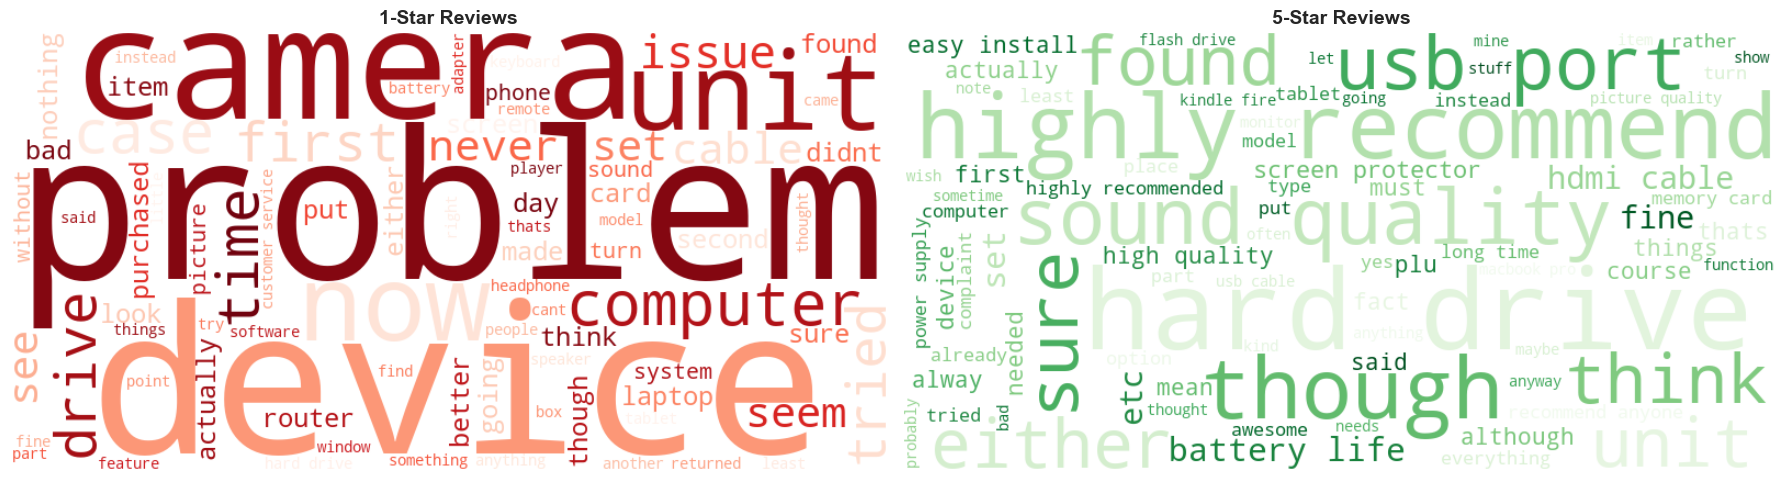

In [21]:
from wordcloud import WordCloud
from collections import Counter
import re

# grab review texts for extreme ratings
text_1star = ' '.join(df[df['overall']==1]['reviewText'].dropna())
text_5star = ' '.join(df[df['overall']==5]['reviewText'].dropna())

# basic stopwords - didn't want to install nltk just for this
stop = {'the','a','an','and','or','but','in','on','at','to','for','of','is','it',
        'this','that','was','with','as','are','be','have','has','had','not','from',
        'they','we','my','i','you','he','she','so','no','do','if','me','its','our',
        'by','one','all','would','there','their','what','about','up','out','can',
        'been','just','more','when','very','how','will','than','into','some','them',
        'other','only','also','did','get','got','could','these','were','which','who',
        'after','then','had','each','make','like','use','her','him','two','way','may',
        'over','such','even','most','any','new','used','work','back','well','much',
        'own','us','say','does','went','know','need','here','come','thing','really',
        'product','bought','buy','amazon','great','good','works','dont','doesnt','ive',
        'still','much','many','using','take','want','because','since'}

def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in stop and len(w) > 2]
    return ' '.join(words)

clean_1 = clean(text_1star)
clean_5 = clean(text_5star)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

wc1 = WordCloud(width=800, height=400, background_color='white',
                colormap='Reds', max_words=80).generate(clean_1)
ax1.imshow(wc1, interpolation='bilinear')
ax1.set_title('1-Star Reviews', fontsize=14, fontweight='bold')
ax1.axis('off')

wc5 = WordCloud(width=800, height=400, background_color='white',
                colormap='Greens', max_words=80).generate(clean_5)
ax2.imshow(wc5, interpolation='bilinear')
ax2.set_title('5-Star Reviews', fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

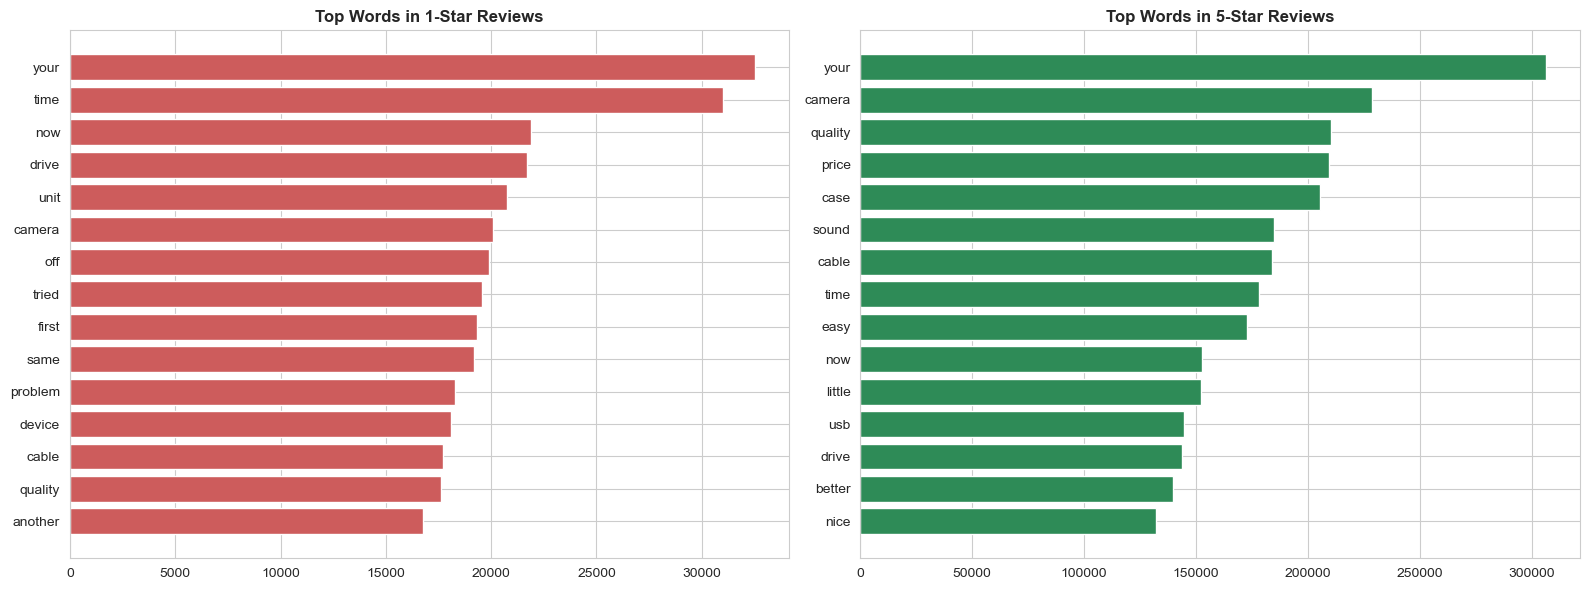

In [22]:
# top 15 words for each group
words_1 = Counter(clean_1.split()).most_common(15)
words_5 = Counter(clean_5.split()).most_common(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.barh([w[0] for w in words_1], [w[1] for w in words_1], color='indianred')
ax1.invert_yaxis()
ax1.set_title('Top Words in 1-Star Reviews', fontweight='bold')

ax2.barh([w[0] for w in words_5], [w[1] for w in words_5], color='seagreen')
ax2.invert_yaxis()
ax2.set_title('Top Words in 5-Star Reviews', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 Common Bigrams

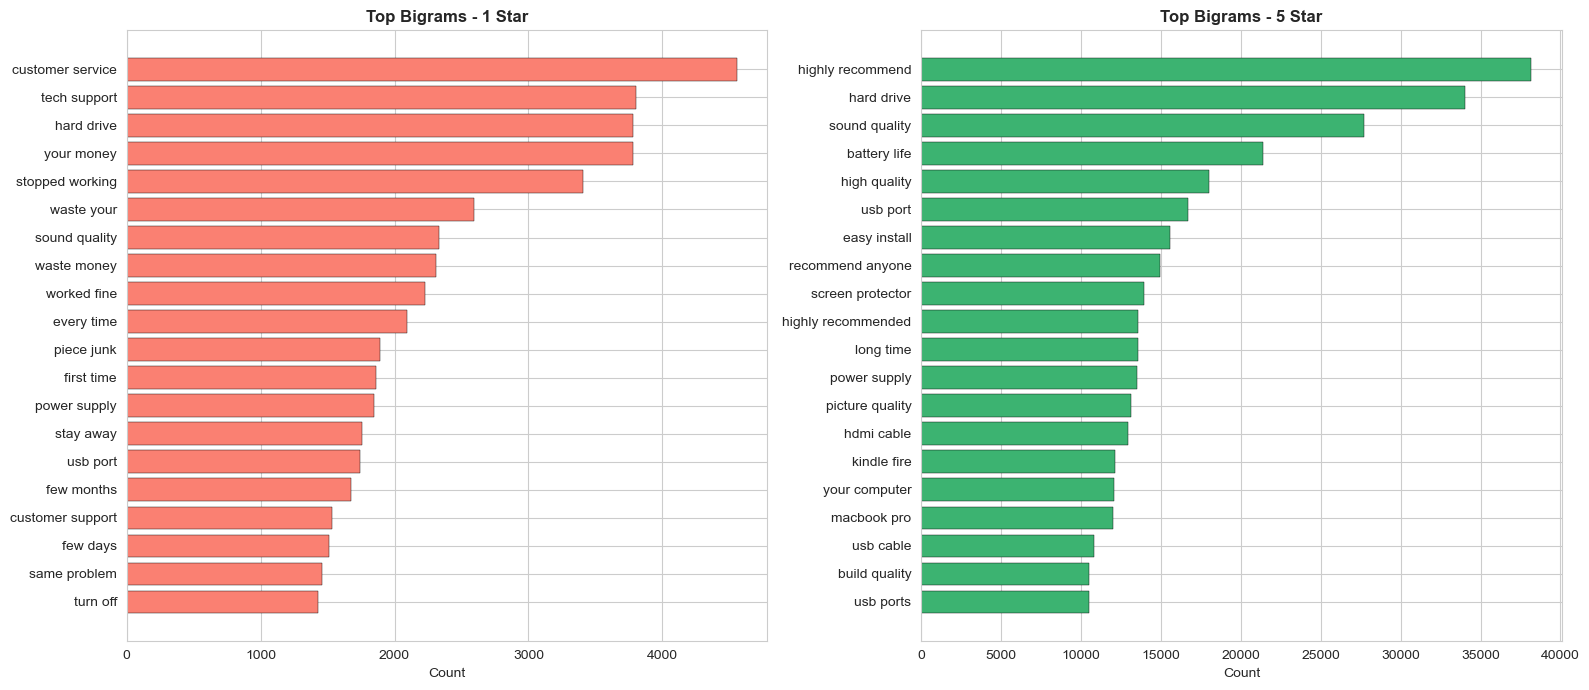

Some notable bigrams:
  1-star: customer service, tech support, hard drive, your money, stopped working
  5-star: highly recommend, hard drive, sound quality, battery life, high quality


In [23]:
# extract bigrams (two-word phrases)
def get_bigrams(text, n=20):
    words = text.split()
    bigrams = [f'{words[i]} {words[i+1]}' for i in range(len(words)-1)]
    return Counter(bigrams).most_common(n)

bi_1 = get_bigrams(clean_1)
bi_5 = get_bigrams(clean_5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

ax1.barh([b[0] for b in bi_1], [b[1] for b in bi_1], color='salmon', edgecolor='black', lw=0.3)
ax1.invert_yaxis()
ax1.set_title('Top Bigrams - 1 Star', fontweight='bold')
ax1.set_xlabel('Count')

ax2.barh([b[0] for b in bi_5], [b[1] for b in bi_5], color='mediumseagreen', edgecolor='black', lw=0.3)
ax2.invert_yaxis()
ax2.set_title('Top Bigrams - 5 Star', fontweight='bold')
ax2.set_xlabel('Count')

plt.tight_layout()
plt.show()

# print some interesting ones
print("Some notable bigrams:")
print(f"  1-star: {', '.join([b[0] for b in bi_1[:5]])}")
print(f"  5-star: {', '.join([b[0] for b in bi_5[:5]])}")